# Method Comparison — Stage 6 Oracle Simulation

Generic analysis notebook for any model / workload / tree config produced
by the Stage 6 pipeline. Auto-discovers all `{workload}_steps{N}/`
directories under the selected `MODEL_DIR`, then renders bar charts /
scatter / budget sensitivity for one configuration at a time.

**Usage**:
1. Set `MODEL_DIR` to the model's output root (e.g. `../results/qwen3_14b`).
2. Pick `SELECTED` from the auto-discovered keys (printed when the
   config cell runs).
3. Optionally toggle `USE_REAL_COST` and `RATIO_CHART_BUDGET`.

Sections 1–6 operate on the selected config. Section 7 overlays the
selected workload's steps sweep (e.g. specbench steps={2,4,6,8}).
Section 8 compares workloads at the same steps.

In [15]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.size': 11,
    'figure.dpi': 100,
})

In [16]:
# ========== SELECT CONFIG AND COST MODE HERE ==========
import os
import re
from pathlib import Path

# >>> CHANGE THESE <<<
MODEL_DIR = "../results/qwen3_14b"
# MODEL_DIR = "../results/qwen3_8b"
# MODEL_DIR = "../results/mango3/qwen3_8b"
USE_REAL_COST = False       # True = measured latencies, False = ratio-based
RATIO = 0.1                # only used when USE_REAL_COST = False
RATIO_CHART_BUDGET = 128   # reference budget for the ratio-sweep chart (§4)

# SELECTED can be:
#   - a workload name ("specbench") → primary config auto-picked, and
#     §1/§2/§3/§5 aggregate best-per-method across ALL configs of the workload
#   - a full v2 dir name ("specbench_steps6_topk16_b128_req0-2")
#   - a prefix without _req ("specbench_steps6_topk16_b128")
#   - legacy names ("specbench_steps6", "bfcl_v4_req576-579")
SELECTED = "specbench"
# SELECTED = "bfcl_v4"
# SELECTED = "swebench"

# Auto-discover any sub-directory that contains tree_oracle_sim.json
# Understands three naming conventions:
#   v2 : {workload}_steps{S}_topk{K}_b{B}_req{X-Y}
#   v1 : {workload}_steps{S}
#   v0 : {workload}_req{X-Y}
WORKLOAD_OPTIONS = {}

_rgx_v2 = re.compile(
    r"^(?P<workload>.+?)_steps(?P<steps>\d+)_topk(?P<topk>\d+)_b(?P<budget>\d+)_req(?P<req>[0-9]+-[0-9]+)$")
_rgx_v1_steps = re.compile(r"^(?P<workload>.+?)_steps(?P<steps>\d+)$")
_rgx_v0_req   = re.compile(r"^(?P<workload>.+?)_req(?P<req>[0-9]+-[0-9]+)$")


def _parse_dir_name(name):
    m = _rgx_v2.match(name)
    if m:
        d = m.groupdict()
        return {"workload": d["workload"], "steps": int(d["steps"]),
                "topk": int(d["topk"]), "budget": int(d["budget"]),
                "req": d["req"], "format": "v2"}
    m = _rgx_v1_steps.match(name)
    if m:
        d = m.groupdict()
        return {"workload": d["workload"], "steps": int(d["steps"]),
                "topk": None, "budget": None, "req": None, "format": "v1"}
    m = _rgx_v0_req.match(name)
    if m:
        d = m.groupdict()
        return {"workload": d["workload"], "steps": None, "topk": None,
                "budget": None, "req": d["req"], "format": "v0"}
    return {"workload": name, "steps": None, "topk": None, "budget": None,
            "req": None, "format": "unknown"}


def _make_label(info):
    parts = []
    if info["steps"]  is not None: parts.append(f"s={info['steps']}")
    if info["topk"]   is not None: parts.append(f"k={info['topk']}")
    if info["budget"] is not None: parts.append(f"b={info['budget']}")
    if not parts and info["req"] is not None: parts.append(f"req={info['req']}")
    return " ".join(parts) if parts else "(default)"


_base = Path(MODEL_DIR)
if _base.exists():
    for sub in sorted(_base.iterdir()):
        if not sub.is_dir():
            continue
        # Priority: _new > _ours > default. _new is this-week's rerun
        # with current code (virtual-root + trim); _ours is last-week's
        # re-sim; default is the ORIGINAL Stage 6 output.
        new_p  = sub / "tree_oracle_sim_new.json"
        ours   = sub / "tree_oracle_sim_ours.json"
        default = sub / "tree_oracle_sim.json"
        if new_p.exists():
            path = new_p
        elif ours.exists():
            path = ours
        else:
            path = default
        if not path.exists():
            continue
        info = _parse_dir_name(sub.name)
        label = f"{info['workload']} {_make_label(info)}".strip()
        WORKLOAD_OPTIONS[sub.name] = (label, str(path), info)

if not WORKLOAD_OPTIONS:
    raise RuntimeError(f"No tree_oracle_sim*.json found under {MODEL_DIR}.")


def _primary_key(info):
    """Ranking key for 'primary' config (largest = preferred)."""
    return (info.get("budget") or 0, info.get("topk") or 0,
            info.get("steps") or 0)


def _resolve_selected(sel, options):
    """Return (primary_key, workload_name).

    Priority:
        1. Exact dir name match (sel is a specific config)
        2. Workload-only match (sel is a workload name)
        3. Prefix match (sel is a partial config key, e.g. without _req)
    """
    if sel is None:
        pkey = next(iter(options))
        return pkey, options[pkey][2]["workload"]
    # 1. Exact dir name
    if sel in options:
        return sel, options[sel][2]["workload"]
    # 2. Workload-only: sel is exactly a known workload name
    cand = [k for k, (_, _, info) in options.items() if info["workload"] == sel]
    if cand:
        cand.sort(key=lambda k: _primary_key(options[k][2]), reverse=True)
        return cand[0], sel
    # 3. Prefix match ({sel}_req…) — for partial v2 keys like
    #    "specbench_steps6_topk16_b128" (missing _req suffix)
    cand = [k for k in options if k.startswith(sel + "_req")]
    if cand:
        cand.sort(key=lambda k: _primary_key(options[k][2]), reverse=True)
        return cand[0], options[cand[0]][2]["workload"]
    raise RuntimeError(
        f"SELECTED='{sel}' not resolvable.\nAvailable: {list(options.keys())}")


SELECTED, SELECTED_WORKLOAD = _resolve_selected(SELECTED, WORKLOAD_OPTIONS)
SELECTED_INFO = WORKLOAD_OPTIONS[SELECTED][2]

# All configs for this workload with MATCHING FORMAT (v2 configs are not
# pooled with legacy v0/v1 — otherwise mdf_global gets rows with None
# steps/topk/budget which render as "NaN" in bar labels).
_sel_fmt = SELECTED_INFO['format']
WORKLOAD_CONFIGS = [
    (k, v) for k, v in WORKLOAD_OPTIONS.items()
    if v[2]["workload"] == SELECTED_WORKLOAD and v[2]["format"] == _sel_fmt
]
WORKLOAD_CONFIGS.sort(key=lambda kv: _primary_key(kv[1][2]), reverse=True)

print(f"Workload: {SELECTED_WORKLOAD}")
print(f"Primary config (for per-config cells): {SELECTED}")
print(f"All configs for {SELECTED_WORKLOAD} ({len(WORKLOAD_CONFIGS)}):")
for k, (lbl, _, info) in WORKLOAD_CONFIGS:
    mark = " ← primary" if k == SELECTED else ""
    print(f"  {k}{mark}")
print()

workload_name, workload_path, _ = WORKLOAD_OPTIONS[SELECTED]
with open(workload_path) as f:
    data = json.load(f)

# vanilla_step_ms: prefer per-run latency_config, then shared model-level config.
latency_candidates = [
    Path("../config/latency") / f"{Path(MODEL_DIR).name}.json",
    Path(workload_path).parent / "latency_config_ours.json",
    Path(workload_path).parent / "latency_config.json",
    Path(MODEL_DIR) / "latency_config.json",
]
vanilla_ms = None
for lp in latency_candidates:
    if not lp.exists():
        continue
    try:
        with open(lp) as f:
            lc = json.load(f)
        vanilla_ms = lc['vanilla_step_ms']
        print(f"Loaded vanilla_step_ms={vanilla_ms:.3f} from {lp}")
        break
    except Exception:
        continue
if vanilla_ms is None:
    vanilla_ms = float(data.get('latency', {}).get('vanilla_step_ms', 0.0)) or 1.0
    print(f"Using fallback vanilla_step_ms={vanilla_ms:.3f}")

COST_LABEL = "real cost" if USE_REAL_COST else f"ratio={RATIO}"

print()
if USE_REAL_COST:
    print("Draft cost: REAL (measured latencies)")
else:
    print(f"Draft cost ratio: {RATIO} (step = verify × {1+RATIO:.2f})")
print(f"Ratio-chart reference budget (§4 only): B={RATIO_CHART_BUDGET}")


Workload: specbench
Primary config (for per-config cells): specbench_steps8_topk16_b128_req0-2
All configs for specbench (9):
  specbench_steps8_topk16_b128_req0-2 ← primary
  specbench_steps6_topk16_b128_req0-2
  specbench_steps4_topk16_b128_req0-2
  specbench_steps2_topk16_b128_req0-2
  specbench_steps8_topk8_b128_req0-2
  specbench_steps6_topk8_b128_req0-2
  specbench_steps4_topk8_b128_req0-2
  specbench_steps8_topk4_b64_req0-2
  specbench_steps6_topk4_b64_req0-2

Loaded vanilla_step_ms=40.754 from ../config/latency/qwen3_14b.json

Draft cost ratio: 0.1 (step = verify × 1.10)
Ratio-chart reference budget (§4 only): B=128


In [17]:
# Parse budget table
df = pd.DataFrame(data["latency"]["budget_sweep"])

# Speedup key: real-cost or ratio-based
spd_suffix = "_speedup_real" if USE_REAL_COST else f"_speedup_r{RATIO}"

# HIDE_METHODS was used to hide legacy choose-one / union-trie columns
HIDE_METHODS = set()  # legacy placeholder: c1/union_trie/eu methods no longer produced

# Always-at-max-budget: suffix (budget-independent, benefits from full tree)
MAX_BUDGET_METHODS = {'suffix'}

max_budget = int(df['budget'].max())
methods = []
for col in df.columns:
    if col.endswith(spd_suffix):
        name = col.replace(spd_suffix, '')
        if name.endswith('_always'):
            continue
        if name in HIDE_METHODS:
            continue
        if name in MAX_BUDGET_METHODS:
            row = df[df['budget'] == max_budget]
            idx = row.index[0]
        else:
            idx = df[col].idxmax()
        best_b = int(df['budget'].iloc[idx])
        mc = f'{name}_mat'
        methods.append({
            'method': name,
            'best_budget': best_b,
            'speedup': df[col].iloc[idx],
            'mat': df[mc].iloc[idx] if mc in df.columns else 0,
        })

mdf_all = pd.DataFrame(methods)

# Keep only best threshold per hybrid group
for prefix in ['hybrid_e3_t', 'hybrid_dm_t']:
    mask = mdf_all['method'].str.startswith(prefix)
    group = mdf_all[mask]
    if len(group) > 1:
        best_idx = group['speedup'].idxmax()
        drop_idx = group.index[group.index != best_idx]
        mdf_all = mdf_all.drop(drop_idx)

# ---------- Extension variant taxonomy ----------
def _ext_taxonomy(name):
    if not name.startswith('extension'):
        return None, None
    is_dm = name.startswith('extension_dmsfx')
    base = 'dm' if is_dm else 'e3'
    rest = name[len('extension_dmsfx'):] if is_dm else name[len('extension'):]
    if rest == '':
        fam = 'basic'
    elif rest == '_oracle':
        fam = 'oracle'
    elif rest.startswith('_by_count_score'):
        fam = 'count_score'
    elif rest.startswith('_by_count'):
        fam = 'count'
    elif rest.startswith('_by_score'):
        fam = 'score'
    elif rest.startswith('_by_pathprob'):
        fam = 'pathprob'
    elif rest.startswith('_by_pt'):
        fam = 'pt'
    else:
        fam = 'other'
    return base, fam

mdf_all['ext_base'], mdf_all['ext_family'] = zip(
    *mdf_all['method'].map(_ext_taxonomy))

mdf_ext = mdf_all[mdf_all['ext_base'].notna()].copy().reset_index(drop=True)

# Main chart scope: only the four extension entries — shown in this
# order via the ORDER index further below:
#   extension, extension_dmsfx, extension_oracle, extension_dmsfx_oracle.
MAIN_EXT_METHODS = ['extension', 'extension_dmsfx',
                    'extension_oracle', 'extension_dmsfx_oracle']

ext_main = mdf_all[mdf_all['method'].isin(MAIN_EXT_METHODS)].copy()
mdf = mdf_all[mdf_all['ext_base'].isna()].copy()
if len(ext_main) > 0:
    mdf = pd.concat([mdf, ext_main], ignore_index=True)
mdf = mdf.reset_index(drop=True)

# Labels
def make_label(name):
    labels = {
        'eagle3': 'EAGLE3',
        'suffix': 'Suffix',
        'draft_model': 'Draft Model',
        'extension': 'Extension (E3+Sfx)',
        'extension_dmsfx': 'Extension (DM+Sfx)',
        'extension_oracle': 'Ext(E3+Sfx) oracle',
        'extension_dmsfx_oracle': 'Ext(DM+Sfx) oracle',
        'extension_by_count': 'Ext(E3+Sfx,count)',
        'extension_dmsfx_by_count': 'Ext(DM+Sfx,count)',
    }
    if name in labels:
        return labels[name]
    if name.startswith('hybrid_e3'):
        t = name.split('_t')[1]
        return f'Hybrid(Sfx->E3) t={t}'
    if name.startswith('hybrid_dm'):
        t = name.split('_t')[1]
        return f'Hybrid(Sfx->DM) t={t}'
    if name.startswith('extension_dmsfx_by_score_t'):
        t = name.split('_t')[1]
        return f'Ext(DM+Sfx,score) t={t}'
    if name.startswith('extension_by_score_t'):
        t = name.split('_t')[1]
        return f'Ext(E3+Sfx,score) t={t}'
    if name.startswith('extension_by_pathprob_t'):
        t = name.split('_t')[1]
        return f'Ext(E3+Sfx,pathp) t={t}'
    return name

ORDER = [
    'eagle3', 'suffix', 'draft_model',
    'hybrid_e3', 'hybrid_dm',
    'extension', 'extension_dmsfx',
    'extension_by_count', 'extension_dmsfx_by_count',
    'extension_by_count_score', 'extension_dmsfx_by_count_score',
    'extension_by_score', 'extension_dmsfx_by_score',
    'extension_by_pathprob', 'extension_by_pt',
    'extension_oracle', 'extension_dmsfx_oracle',
]

def get_order(name):
    if name.startswith('hybrid_e3'):
        return ORDER.index('hybrid_e3')
    if name.startswith('hybrid_dm'):
        return ORDER.index('hybrid_dm')
    if name.startswith('extension_dmsfx_by_score'):
        return ORDER.index('extension_dmsfx_by_score')
    if name.startswith('extension_by_score'):
        return ORDER.index('extension_by_score')
    if name.startswith('extension_by_pathprob'):
        return ORDER.index('extension_by_pathprob')
    return ORDER.index(name) if name in ORDER else len(ORDER)

def get_color(name):
    if name == 'eagle3': return '#2ca02c'
    if name == 'suffix': return '#ff7f0e'
    if name == 'draft_model': return '#8c564b'
    if 'hybrid_e3' in name: return '#9467bd'
    if 'hybrid_dm' in name: return '#e377c2'
    if name == 'extension': return '#d62728'
    if name == 'extension_dmsfx': return '#fc8d8d'
    if name == 'extension_oracle': return '#7a0000'
    if name == 'extension_dmsfx_oracle': return '#a83232'
    if name == 'extension_by_count': return '#ef4040'
    if name == 'extension_dmsfx_by_count': return '#ffa0a0'
    if name.startswith('extension_dmsfx_by_score'): return '#c94a4a'
    if name.startswith('extension_by_score'): return '#a51717'
    if name.startswith('extension_by_pathprob'): return '#b22222'
    return '#7f7f7f'

mdf['label'] = mdf['method'].map(make_label)
mdf['color'] = mdf['method'].map(get_color)
mdf['order'] = mdf['method'].map(get_order)
mdf = mdf.sort_values('order').reset_index(drop=True)

print(f"Methods in main chart: {len(mdf)}, cost={COST_LABEL}")
print(mdf[['label', 'best_budget', 'speedup', 'mat']].to_string(index=False))
print()
print(f"Extension variants collected: {len(mdf_ext)}  "
      "(detailed comparison in §9)")

# =================================================================
# GLOBAL aggregation across all configs of SELECTED_WORKLOAD.
# For each method, pick best speedup over (config × internal budget).
# Used by §1, §2, §3, §5 — so the bar charts reflect the global optimum
# rather than being capped at whatever (steps, topk, budget-cap) the
# primary config has.
# =================================================================
_global_entries = []
for _k, (_lbl, _path, _info) in WORKLOAD_CONFIGS:
    with open(_path) as _f:
        _d = json.load(_f)
    _df = pd.DataFrame(_d['latency']['budget_sweep'])
    for _col in _df.columns:
        if not _col.endswith(spd_suffix):
            continue
        _name = _col.replace(spd_suffix, '')
        if _name.endswith('_always') or _name in HIDE_METHODS:
            continue
        if _name in MAX_BUDGET_METHODS:
            _row = _df[_df['budget'] == int(_df['budget'].max())]
            _idx = _row.index[0]
        else:
            _idx = _df[_col].idxmax()
        _b = int(_df['budget'].iloc[_idx])
        _mc = f'{_name}_mat'
        _global_entries.append({
            'method': _name,
            'speedup': _df[_col].iloc[_idx],
            'best_budget': _b,
            'mat': _df[_mc].iloc[_idx] if _mc in _df.columns else 0,
            'cfg_key': _k,
            'cfg_steps': _info.get('steps'),
            'cfg_topk': _info.get('topk'),
            'cfg_budget_cap': _info.get('budget'),
        })

_mdf_global_all = pd.DataFrame(_global_entries)
# Pick the row with max speedup per method
mdf_global_all = (
    _mdf_global_all.sort_values('speedup', ascending=False)
    .drop_duplicates(subset=['method'], keep='first')
    .reset_index(drop=True))

# Keep only best threshold per hybrid group
for prefix in ['hybrid_e3_t', 'hybrid_dm_t']:
    mask = mdf_global_all['method'].str.startswith(prefix)
    group = mdf_global_all[mask]
    if len(group) > 1:
        best_idx = group['speedup'].idxmax()
        drop_idx = group.index[group.index != best_idx]
        mdf_global_all = mdf_global_all.drop(drop_idx)

# Apply the same extension taxonomy + main-chart scope as mdf
mdf_global_all['ext_base'], mdf_global_all['ext_family'] = zip(
    *mdf_global_all['method'].map(_ext_taxonomy))

ext_main_g = mdf_global_all[mdf_global_all['method'].isin(MAIN_EXT_METHODS)].copy()
mdf_global = mdf_global_all[mdf_global_all['ext_base'].isna()].copy()
if len(ext_main_g) > 0:
    mdf_global = pd.concat([mdf_global, ext_main_g], ignore_index=True)

mdf_global['label'] = mdf_global['method'].map(make_label)
mdf_global['color'] = mdf_global['method'].map(get_color)
mdf_global['order'] = mdf_global['method'].map(get_order)
mdf_global = mdf_global.sort_values('order').reset_index(drop=True)

# Human-friendly provenance tag
def _cfg_tag(row):
    s = row.get('cfg_steps'); k = row.get('cfg_topk'); b = row.get('cfg_budget_cap')
    parts = []
    if s is not None: parts.append(f"steps={s}")
    if k is not None: parts.append(f"topk={k}")
    if b is not None: parts.append(f"budget={b}")
    return ", ".join(parts) if parts else row.get('cfg_key', '?')

mdf_global['cfg_tag'] = mdf_global.apply(_cfg_tag, axis=1)

print()
print(f"GLOBAL aggregation ({SELECTED_WORKLOAD}, {len(WORKLOAD_CONFIGS)} configs):")
print(mdf_global[['label', 'cfg_tag', 'best_budget', 'speedup', 'mat']].to_string(index=False))

# =================================================================
# Per-variant best across all configs (for §9 Extension Variants).
# mdf_ext_global has ALL extension variants (not just MAIN_EXT_METHODS)
# — each row = the winning (config, budget) for that variant.
# =================================================================
mdf_ext_global = mdf_global_all[mdf_global_all['ext_base'].notna()].copy()
mdf_ext_global['label'] = mdf_ext_global['method'].map(make_label)
mdf_ext_global['color'] = mdf_ext_global['method'].map(get_color)
mdf_ext_global['cfg_tag'] = mdf_ext_global.apply(_cfg_tag, axis=1)
mdf_ext_global = mdf_ext_global.reset_index(drop=True)
print(f"\nExtension variants (global): {len(mdf_ext_global)}")


Methods in main chart: 9, cost=ratio=0.1
                 label  best_budget  speedup      mat
                EAGLE3          128 2.654578 1.920036
                Suffix          128 1.327206 0.327206
           Draft Model           16 2.972652 2.269618
Hybrid(Sfx->E3) t=10.0          128 2.650897 1.906977
Hybrid(Sfx->DM) t=20.0           16 2.977008 2.272910
    Extension (E3+Sfx)          128 3.111005 2.422105
    Extension (DM+Sfx)           16 3.317008 2.648709
    Ext(E3+Sfx) oracle          128 3.111005 2.422105
    Ext(DM+Sfx) oracle           16 3.317008 2.648709

Extension variants collected: 48  (detailed comparison in §9)

GLOBAL aggregation (specbench, 9 configs):
                 label     cfg_tag  best_budget  speedup      mat
                EAGLE3 s4/k16/b128          128 2.668470 1.935077
                Suffix  s4/k8/b128          128 1.419102 0.419102
           Draft Model   s6/k4/b64           16 3.056393 2.361742
Hybrid(Sfx->E3) t=10.0 s4/k16/b128          128 

## 1. Speedup Comparison

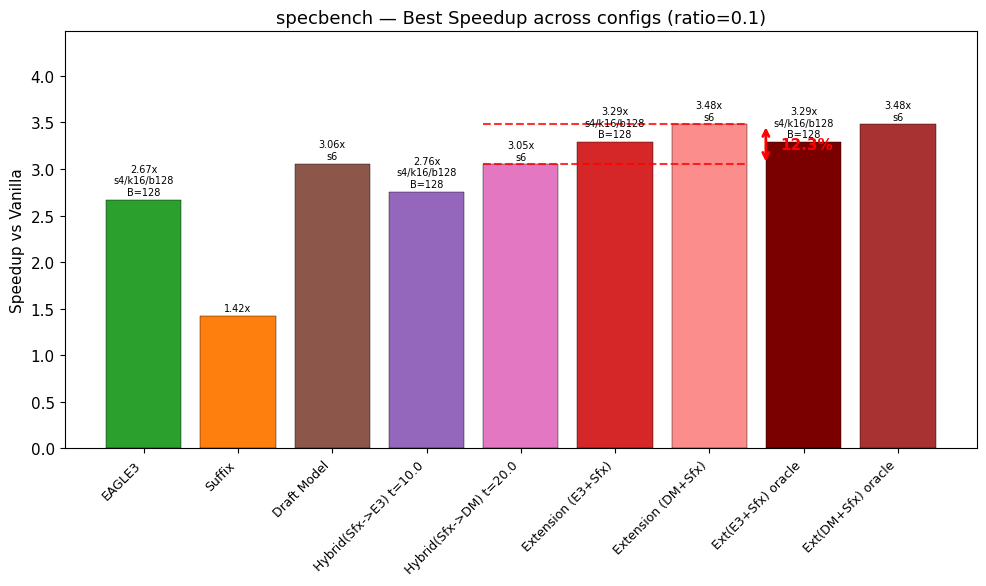

In [18]:
# Uses mdf_global (best-per-method across ALL configs of the workload).
fig, ax = plt.subplots(figsize=(max(10, len(mdf_global) * 0.8), 6))

x = np.arange(len(mdf_global))
bars = ax.bar(x, mdf_global['speedup'].values, color=mdf_global['color'].values,
              edgecolor='black', linewidth=0.3)

# Per-method label:
#   suffix → just speedup (model-free)
#   draft_model → speedup + s={steps} (no topk/budget, linear chain)
#   others → speedup + s/k/b (config) + B=internal_budget
def _mk_label(row):
    name = row['method']
    val = row['speedup']
    s = row.get('cfg_steps')
    k = row.get('cfg_topk')
    b = row.get('cfg_budget_cap')
    ib = row['best_budget']
    head = f"{val:.2f}x"
    if name == 'suffix':
        return head
    # DM-based methods: steps-only label (topk/budget not relevant for linear chain).
    if (name == 'draft_model'
            or name.startswith('hybrid_dm')
            or name.startswith('extension_dmsfx')):
        return f"{head}\nsteps={s}" if s is not None else head
    parts = []
    if s is not None: parts.append(f"steps={s}")
    if k is not None: parts.append(f"topk={k}")
    if b is not None: parts.append(f"budget={b}")
    tag = ", ".join(parts)
    return f"{head}\n{tag}\nB={ib}"

for i, row in mdf_global.iterrows():
    txt = _mk_label(row)
    ax.text(i, row['speedup'] + 0.03, txt, ha='center', va='bottom', fontsize=7)

# Gap annotation: best realistic extension (excluding oracle variants) vs
# best hybrid. The oracle methods are upper bounds (they assume knowing
# which suffix chains to verify beforehand) and so don't represent
# deployable settings — compare against practical extension instead.
def _is_hybrid(m):
    return (m.startswith('hybrid_e3_t') or m.startswith('hybrid_dm_t')) \
        and not m.endswith('_always')

def _is_realistic_extension(m):
    if not m.startswith('extension'):
        return False
    # Exclude the "oracle" variants (target verifies only accepted path).
    return not (m == 'extension_oracle' or m == 'extension_dmsfx_oracle')

methods_list = list(mdf_global['method'].values)
speedups_list = list(mdf_global['speedup'].values)

best_hyb = None
for i, m in enumerate(methods_list):
    if _is_hybrid(m):
        if best_hyb is None or speedups_list[i] > speedups_list[best_hyb]:
            best_hyb = i

best_ext = None
for i, m in enumerate(methods_list):
    if _is_realistic_extension(m):
        if best_ext is None or speedups_list[i] > speedups_list[best_ext]:
            best_ext = i

if best_hyb is not None and best_ext is not None:
    h_pos, e_pos = best_hyb, best_ext
    h_spd = speedups_list[h_pos]
    e_spd = speedups_list[e_pos]
    pct = abs((h_spd - e_spd) / max(h_spd, e_spd) * 100)

    x_lo, x_hi = sorted([h_pos, e_pos])
    ax.hlines(h_spd, x_lo - 0.4, x_hi + 0.4, colors='red',
              linestyles='--', alpha=0.8, linewidth=1.5)
    ax.hlines(e_spd, x_lo - 0.4, x_hi + 0.4, colors='red',
              linestyles='--', alpha=0.8, linewidth=1.5)

    arrow_x = x_hi + 0.6
    ax.annotate('', xy=(arrow_x, e_spd), xytext=(arrow_x, h_spd),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
    ax.text(arrow_x + 0.15, (h_spd + e_spd) / 2, f'{pct:.1f}%',
            ha='left', va='center', color='red', fontsize=11, fontweight='bold')
    ax.set_ylim(top=max(speedups_list) + 1.0)

ax.set_xticks(x)
ax.set_xticklabels(mdf_global['label'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Speedup vs Vanilla')
ax.set_title(f'{SELECTED_WORKLOAD} — Best Speedup across configs ({COST_LABEL})', fontsize=13)
plt.tight_layout()
plt.show()

## 2. MAT (Mean Accepted Tokens) Comparison

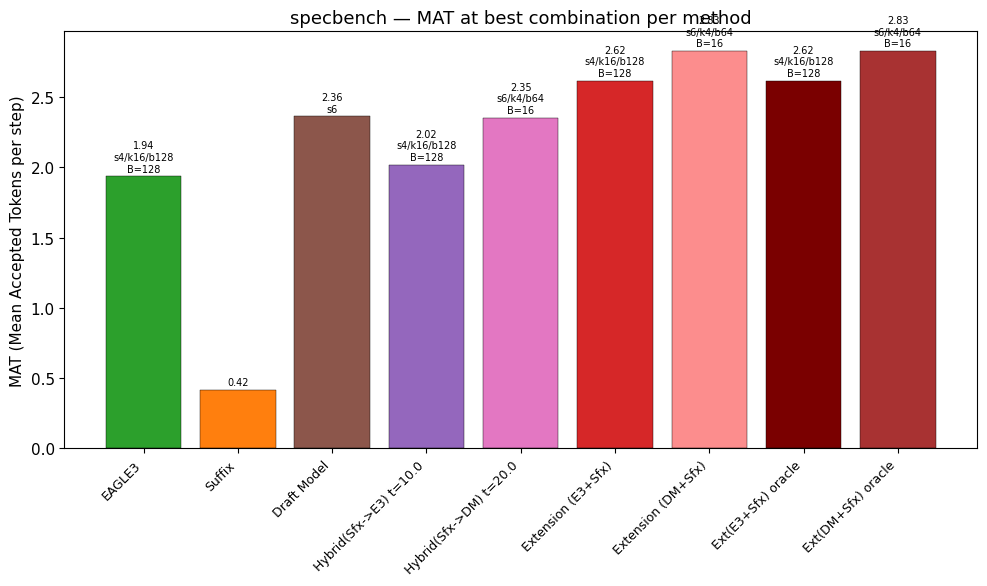

In [19]:
# Uses mdf_global (best-per-method across ALL configs).
mdf_mat = mdf_global[mdf_global['mat'] > 0].copy().reset_index(drop=True)

if len(mdf_mat) > 0:
    fig, ax = plt.subplots(figsize=(max(10, len(mdf_mat) * 0.8), 6))
    
    x = np.arange(len(mdf_mat))
    bars = ax.bar(x, mdf_mat['mat'], color=mdf_mat['color'].values, edgecolor='black', linewidth=0.3)
    
    # Per-method label (same rule as §1).
    def _mk_label(row):
        name = row['method']
        val = row['mat']
        s = row.get('cfg_steps')
        k = row.get('cfg_topk')
        b = row.get('cfg_budget_cap')
        ib = row['best_budget']
        head = f"{val:.2f}"
        if name == 'suffix':
            return head
        if name == 'draft_model':
            return f"{head}\nsteps={s}" if s is not None else head
        parts = []
        if s is not None: parts.append(f"steps={s}")
        if k is not None: parts.append(f"topk={k}")
        if b is not None: parts.append(f"budget={b}")
        tag = ", ".join(parts)
        return f"{head}\n{tag}\nB={ib}"

    for i, row in mdf_mat.iterrows():
        txt = _mk_label(row)
        ax.text(i, row['mat'] + 0.02, txt, ha='center', va='bottom', fontsize=7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(mdf_mat['label'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('MAT (Mean Accepted Tokens per step)')
    ax.set_title(f'{SELECTED_WORKLOAD} — MAT at best combination per method', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No MAT data available')

## 3. Speedup vs MAT Scatter

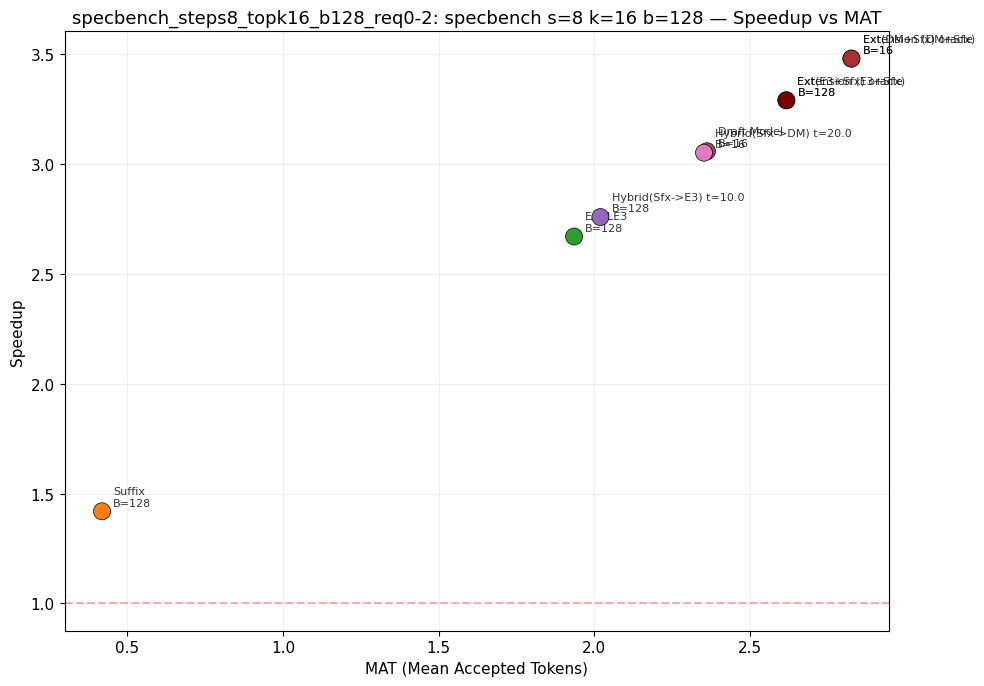

In [20]:
# Uses mdf_global (best-per-method across ALL configs).
mdf_both = mdf_global[mdf_global['mat'] > 0].copy()

if len(mdf_both) > 0:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.scatter(mdf_both['mat'], mdf_both['speedup'],
               c=mdf_both['color'], s=150, edgecolors='black', linewidth=0.5, zorder=5)
    
    for _, r in mdf_both.iterrows():
        ax.annotate(f"{r['label']}\nB={r['best_budget']}",
                    (r['mat'], r['speedup']),
                    textcoords='offset points', xytext=(8, 4),
                    fontsize=8, alpha=0.8)
    
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel('MAT (Mean Accepted Tokens)')
    ax.set_ylabel('Speedup')
    ax.set_title(f'{SELECTED}: {workload_name} — Speedup vs MAT', fontsize=13)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print('No data')

## 4. Speedup across Ratios (Selected Budget)

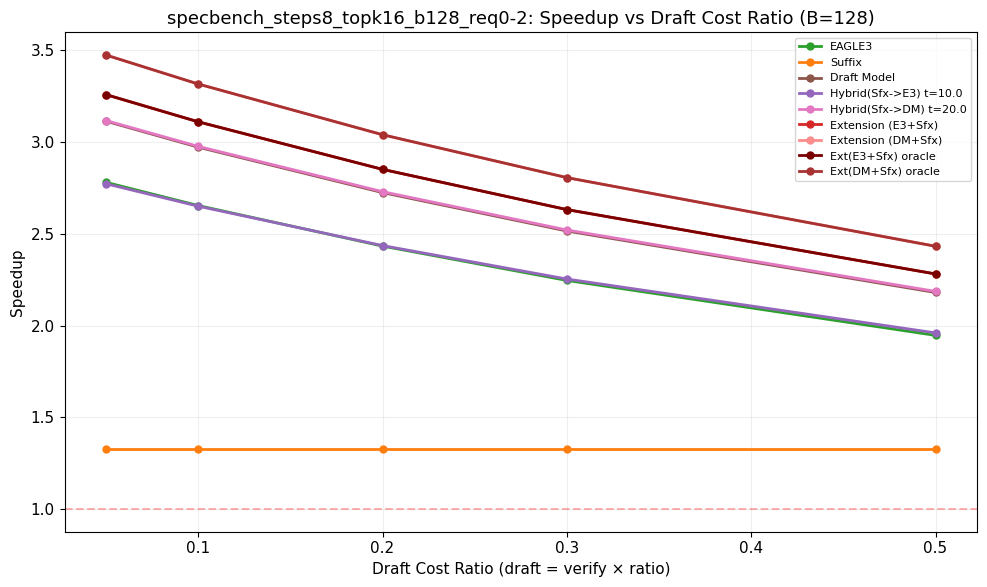

In [21]:
ratios = [0.05, 0.1, 0.2, 0.3, 0.5]
b_row = df[df['budget'] == RATIO_CHART_BUDGET]
if len(b_row) == 0:
    b_row = df.iloc[[-1]]
b_row = b_row.iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))

for _, r in mdf.iterrows():
    name = r['method']
    spds = [b_row.get(f'{name}_speedup_r{ratio}', 0) for ratio in ratios]
    if any(s > 0 for s in spds):
        ax.plot(ratios, spds, 'o-', label=r['label'], color=r['color'], linewidth=2, markersize=5)

ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Draft Cost Ratio (draft = verify × ratio)')
ax.set_ylabel('Speedup')
ax.set_title(f'{SELECTED}: Speedup vs Draft Cost Ratio (B={int(b_row["budget"])})', fontsize=13)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Summary Table

In [22]:
# Uses mdf_global (best-per-method across ALL configs).
print(f"{'='*75}")
print(f"{SELECTED}: {workload_name} ({COST_LABEL})")
print(f"{'='*75}")
print()
print(f"{'Method':<32} {'Budget':>6} {'Speedup':>9} {'MAT':>6}")
print('-' * 57)
for _, r in mdf_global.iterrows():
    mat_str = f"{r['mat']:.2f}" if r['mat'] > 0 else '-'
    print(f"{r['label']:<32} B={r['best_budget']:>3}  {r['speedup']:>7.2f}x {mat_str:>6}")
print(f"{'='*75}")

specbench_steps8_topk16_b128_req0-2: specbench s=8 k=16 b=128 (ratio=0.1)

Method                           Budget   Speedup    MAT
---------------------------------------------------------
EAGLE3                           B=128     2.67x   1.94
Suffix                           B=128     1.42x   0.42
Draft Model                      B= 16     3.06x   2.36
Hybrid(Sfx->E3) t=10.0           B=128     2.76x   2.02
Hybrid(Sfx->DM) t=20.0           B= 16     3.05x   2.35
Extension (E3+Sfx)               B=128     3.29x   2.62
Extension (DM+Sfx)               B= 16     3.48x   2.83
Ext(E3+Sfx) oracle               B=128     3.29x   2.62
Ext(DM+Sfx) oracle               B= 16     3.48x   2.83


## 6. Budget Sensitivity (Selected Methods)

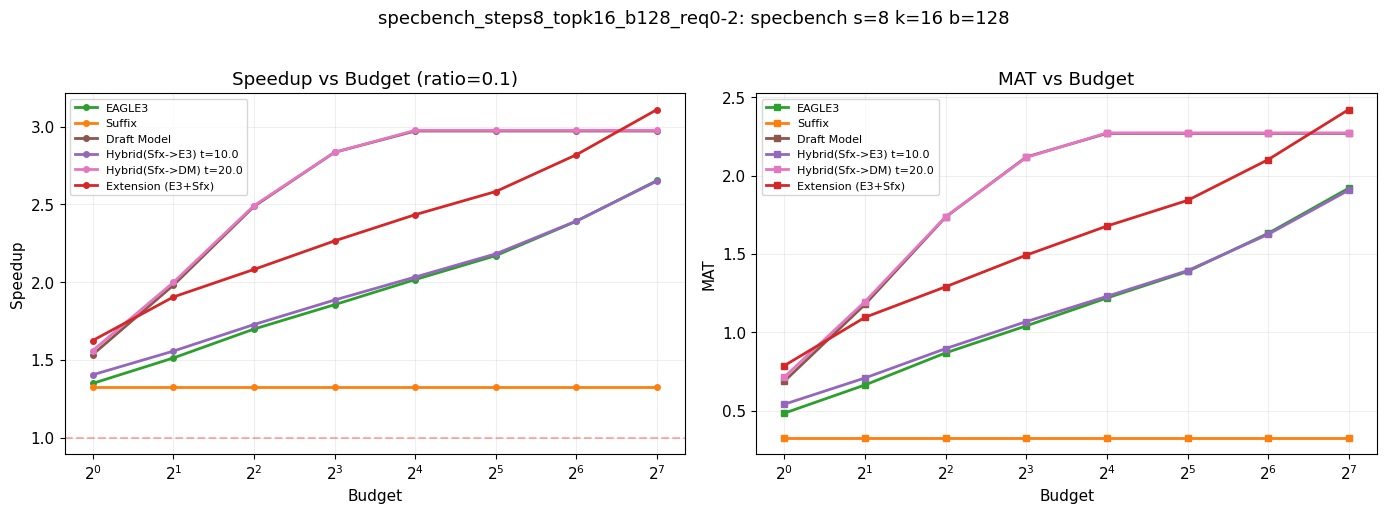

In [23]:
top_methods = mdf.head(6)['method'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in top_methods:
    col_spd = f'{name}{spd_suffix}'
    col_mat = f'{name}_mat'
    label = make_label(name)
    color = get_color(name)

    if col_spd in df.columns:
        ax1.plot(df['budget'], df[col_spd], 'o-', label=label, color=color, linewidth=2, markersize=4)
    if col_mat in df.columns:
        ax2.plot(df['budget'], df[col_mat], 's-', label=label, color=color, linewidth=2, markersize=4)

ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
ax1.set_xlabel('Budget')
ax1.set_ylabel('Speedup')
ax1.set_title(f'Speedup vs Budget ({COST_LABEL})')
ax1.set_xscale('log', base=2)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.2)

ax2.set_xlabel('Budget')
ax2.set_ylabel('MAT')
ax2.set_title('MAT vs Budget')
ax2.set_xscale('log', base=2)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)

plt.suptitle(f'{SELECTED}: {workload_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Cross-axis Comparison (budget / topk / steps × eagle3 / extension / hybrid)

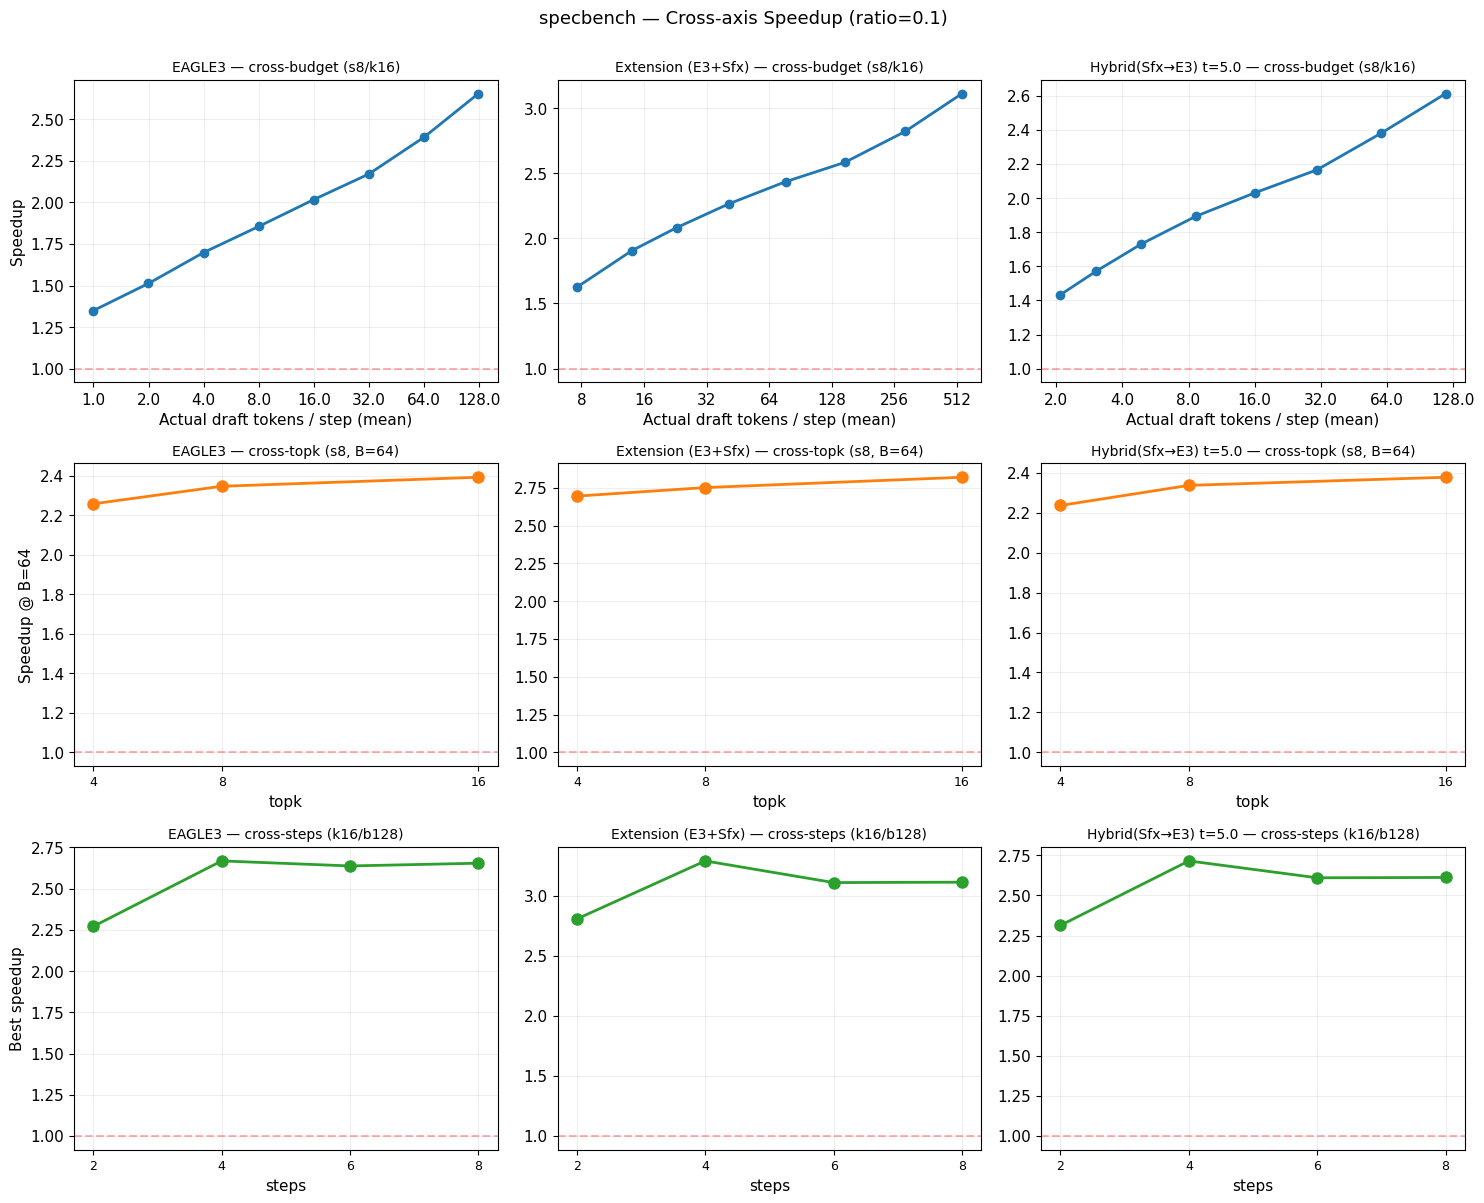

Peers cross-steps: [2, 4, 6, 8]
Peers cross-topk:  [(4, 64), (8, 128), (16, 128)]


In [24]:
# 3×3 grid: rows = sweep axis, cols = method family.
# X-axis per row:
#   Row 1 (cross-budget): budget (internal sweep)  — numeric ticks, not 2^n
#   Row 2 (cross-topk):   topk                     — one point per topk
#   Row 3 (cross-steps):  steps                    — one point per steps
CROSS_METHODS = [
    ('eagle3',         'EAGLE3'),
    ('extension',      'Extension (E3+Sfx)'),
    ('hybrid_e3_t5.0', 'Hybrid(Sfx→E3) t=5.0'),
]

sel_workload = SELECTED_INFO['workload']
sel_steps    = SELECTED_INFO['steps']
sel_topk     = SELECTED_INFO['topk']
sel_budget   = SELECTED_INFO['budget']
sel_req      = SELECTED_INFO['req']


def _peers_cross_steps():
    out = []
    for key, (_, path, info) in WORKLOAD_OPTIONS.items():
        if info['format'] != 'v2': continue
        if (info['workload'] != sel_workload or info['topk'] != sel_topk
                or info['budget'] != sel_budget or info['req'] != sel_req):
            continue
        out.append((info['steps'], path))
    out.sort(key=lambda x: x[0])
    return out


CROSS_TOPK_FIXED_B = 64   # internal budget pinned for cross-topk row
def _peers_cross_topk():
    # All topks at fixed steps. Budget-cap varies (paired with topk in our
    # config: k=4→b=64, k∈{8,16}→b=128) but we read speedup at a FIXED
    # internal budget (B=64) so values are directly comparable.
    out = []
    for key, (_, path, info) in WORKLOAD_OPTIONS.items():
        if info['format'] != 'v2': continue
        if (info['workload'] != sel_workload or info['steps'] != sel_steps
                or info['req'] != sel_req):
            continue
        out.append((info['topk'], info['budget'], path))
    out.sort(key=lambda x: x[0])
    return out


def _best_speedup(path, method):
    """Load the file and return max speedup_real for the method, or None."""
    col = f'{method}{spd_suffix}'
    with open(path) as f:
        d = json.load(f)
    df = pd.DataFrame(d['latency']['budget_sweep'])
    if col not in df.columns: return None
    v = df[col].max()
    return float(v) if not pd.isna(v) else None


peers_steps = _peers_cross_steps()
peers_topk  = _peers_cross_topk()

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=False)

for col, (m, mlabel) in enumerate(CROSS_METHODS):
    col_name = f'{m}{spd_suffix}'

    # --- Row 0: cross-budget (fix topk, steps) ---
    # X-axis = ACTUAL verified draft tokens per step (method-specific):
    #   {method}_total_target_tokens / {method}_steps
    # For eagle3 this equals configured budget (full tree). For extension
    # the extended tree is larger than budget (adds suffix nodes); for
    # hybrid the tree size swings between E3-tree and suffix-only.
    ax = axes[0, col]
    if col_name in df.columns:
        tok_col = f'{m}_total_target_tokens'
        stp_col = f'{m}_steps'
        if tok_col in df.columns and stp_col in df.columns:
            xs = (df[tok_col] / df[stp_col].replace(0, 1)).tolist()
            xlabel = 'Actual draft tokens / step (mean)'
        else:
            xs = df['budget'].tolist()
            xlabel = 'Budget'
        ys = df[col_name].tolist()
        ax.plot(xs, ys, 'o-', color='#1f77b4', linewidth=2, markersize=6)
        ax.set_xscale('log', base=2)
        ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
    ax.set_title(f'{mlabel} — cross-budget (steps={sel_steps}, topk={sel_topk})', fontsize=10)
    ax.set_xlabel(xlabel)
    if col == 0: ax.set_ylabel('Speedup')
    ax.grid(alpha=0.2, which='both')

    # --- Row 1: cross-topk (fixed internal budget = CROSS_TOPK_FIXED_B) ---
    ax = axes[1, col]
    if peers_topk:
        xs, ys = [], []
        for topk_val, budget_val, path in peers_topk:
            with open(path) as f:
                d_i = json.load(f)
            df_i = pd.DataFrame(d_i['latency']['budget_sweep'])
            col_n = f'{m}{spd_suffix}'
            if col_n not in df_i.columns: continue
            row_b = df_i[df_i['budget'] == CROSS_TOPK_FIXED_B]
            if len(row_b) == 0: continue
            v = row_b[col_n].iloc[0]
            if pd.isna(v): continue
            xs.append(topk_val); ys.append(float(v))
        ax.plot(xs, ys, 'o-', color='#ff7f0e', linewidth=2, markersize=8)
        ax.set_xticks(xs)
        ax.set_xticklabels([str(x) for x in xs], fontsize=9)
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
    ax.set_title(f'{mlabel} — cross-topk (steps={sel_steps}, B={CROSS_TOPK_FIXED_B})', fontsize=10)
    ax.set_xlabel('topk')
    if col == 0: ax.set_ylabel(f'Speedup @ B={CROSS_TOPK_FIXED_B}')
    ax.grid(alpha=0.2)

    # --- Row 2: cross-steps (one point per steps config) ---
    ax = axes[2, col]
    if peers_steps:
        xs, ys = [], []
        for steps_val, path in peers_steps:
            v = _best_speedup(path, m)
            if v is None: continue
            xs.append(steps_val); ys.append(v)
        ax.plot(xs, ys, 'o-', color='#2ca02c', linewidth=2, markersize=8)
        ax.set_xticks(xs)
        ax.set_xticklabels([str(x) for x in xs], fontsize=9)
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
    ax.set_title(f'{mlabel} — cross-steps (topk={sel_topk}, budget={sel_budget})', fontsize=10)
    ax.set_xlabel('steps')
    if col == 0: ax.set_ylabel('Best speedup')
    ax.grid(alpha=0.2)

plt.suptitle(f'{sel_workload} — Cross-axis Speedup ({COST_LABEL})',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

print(f'Peers cross-steps: {[p[0] for p in peers_steps]}')
print(f'Peers cross-topk:  {[(p[0],p[1]) for p in peers_topk]}')


## 9. Extension Variants — Detailed Comparison

All extension methods side-by-side, grouped by base proposer (E3+Sfx vs
DM+Sfx) and filter family (no constraint / count / score / ptopk / product /
pathprob / oracle). The oracle variant is shown as a dashed upper-bound.

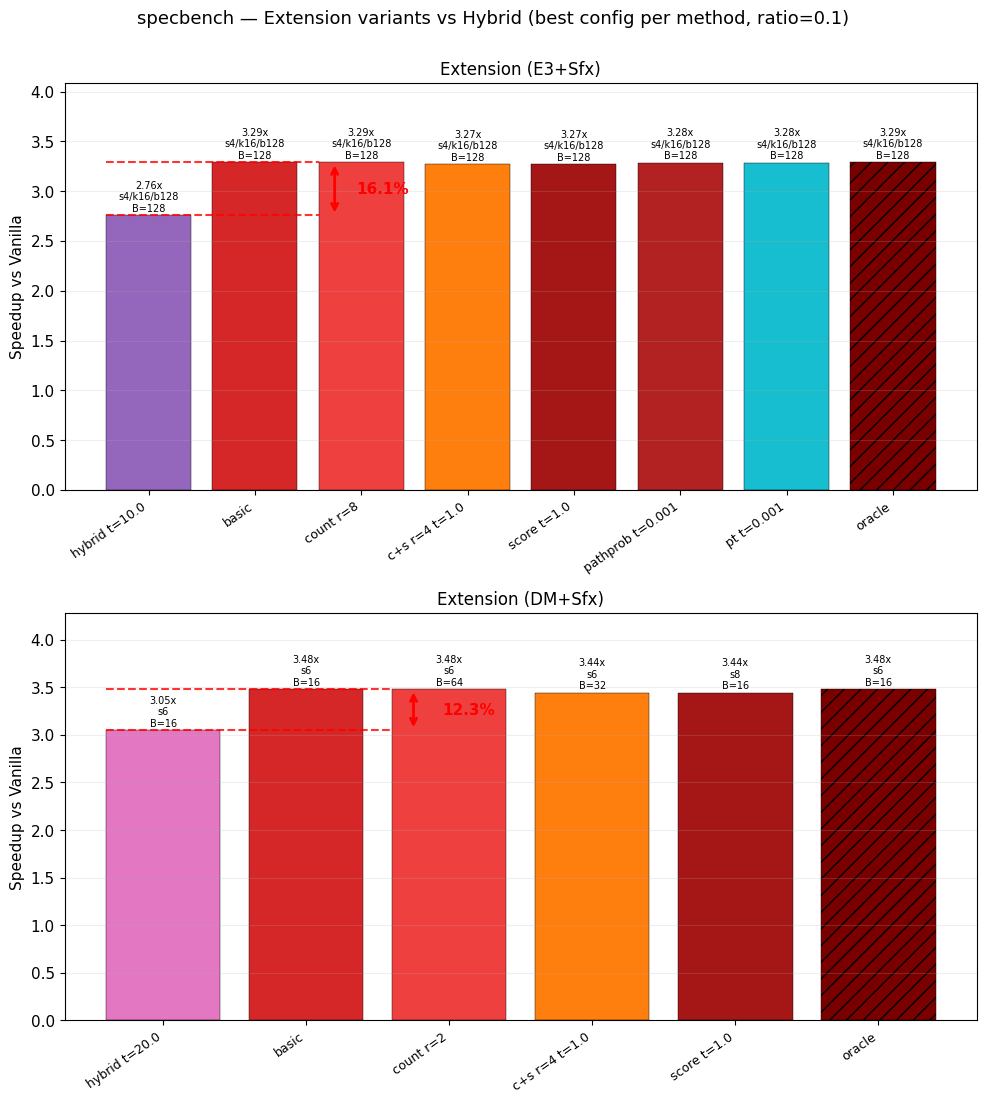


specbench: Best per method (extension + hybrid)

[Extension (E3+Sfx)]
  method     best variant                            B     spd    mat
  hybrid     hybrid_e3_t10.0                       128   2.76x   2.02
  basic      extension                             128   3.29x   2.62
  count      extension_by_count_r8                 128   3.29x   2.62
  count_score extension_by_count_score_r4_t1.0      128   3.27x   2.60
  score      extension_by_score_t1.0               128   3.27x   2.60
  pathprob   extension_by_pathprob_t0.001          128   3.28x   2.61
  pt         extension_by_pt_t0.001                128   3.28x   2.61
  oracle     extension_oracle                      128   3.29x   2.62

[Extension (DM+Sfx)]
  method     best variant                            B     spd    mat
  hybrid     hybrid_dm_t20.0                        16   3.05x   2.35
  basic      extension_dmsfx                        16   3.48x   2.83
  count      extension_dmsfx_by_count_r2            64   3.48x   2

In [25]:
if len(mdf_ext_global) == 0:
    print("No extension variants in this artifact.")
else:
    # All extension families. Per-family best variant is selected.
    FAMILY_ORDER = ['basic', 'count', 'count_score', 'score',
                    'pathprob', 'pt', 'oracle']
    FAMILY_COLOR = {
        'basic':       '#d62728',
        'count':       '#ef4040',
        'count_score': '#ff7f0e',
        'score':       '#a51717',
        'pathprob':    '#b22222',
        'pt':          '#17becf',
        'oracle':      '#7a0000',
    }
    mdf_ext_global = mdf_ext_global[mdf_ext['ext_family'].isin(FAMILY_ORDER)].copy()
    HYBRID_COLOR = {'e3': '#9467bd', 'dm': '#e377c2'}

    # Keep only the best variant per (base, family) to reduce clutter.
    best_per_fam = (
        mdf_ext_global.sort_values('speedup', ascending=False)
               .drop_duplicates(subset=['ext_base', 'ext_family'])
               .reset_index(drop=True)
    )

    # Pull in hybrid baselines for fair comparison — best threshold per
    # (Sfx->E3) / (Sfx->DM) family, already captured in mdf_all.
    hybrid_rows = mdf_global_all[mdf_global_all['method'].str.startswith('hybrid_')].copy()
    hybrid_rows['cfg_tag'] = hybrid_rows.apply(_cfg_tag, axis=1)
    def _hybrid_base(m):
        if m.startswith('hybrid_e3'): return 'e3'
        if m.startswith('hybrid_dm'): return 'dm'
        return None
    hybrid_rows['ext_base'] = hybrid_rows['method'].map(_hybrid_base)
    hybrid_rows['ext_family'] = 'hybrid'

    fig, axes = plt.subplots(2, 1, figsize=(10, 11))
    bases = [('e3', 'Extension (E3+Sfx)'),
             ('dm', 'Extension (DM+Sfx)')]
    for ax, (base, title) in zip(axes, bases):
        fam_sub = best_per_fam[best_per_fam['ext_base'] == base].copy()
        hyb_sub = hybrid_rows[hybrid_rows['ext_base'] == base].copy()
        if len(fam_sub) == 0 and len(hyb_sub) == 0:
            ax.set_title(f'{title} — no data')
            ax.axis('off')
            continue

        # Hybrid first, then families in FAMILY_ORDER
        fam_sub['fam_order'] = fam_sub['ext_family'].map(
            lambda f: FAMILY_ORDER.index(f) if f in FAMILY_ORDER else 99)
        fam_sub = fam_sub.sort_values('fam_order').reset_index(drop=True)
        sub = pd.concat([hyb_sub, fam_sub], ignore_index=True)

        def _row_color(r):
            fam = r['ext_family']
            if fam == 'hybrid':
                return HYBRID_COLOR.get(r['ext_base'], '#7f7f7f')
            return FAMILY_COLOR.get(fam, '#7f7f7f')
        colors = [_row_color(r) for _, r in sub.iterrows()]

        x = np.arange(len(sub))
        bars = ax.bar(x, sub['speedup'], color=colors,
                      edgecolor='black', linewidth=0.3)
        for bar, fam in zip(bars, sub['ext_family']):
            if fam == 'oracle':
                bar.set_hatch('//')
                bar.set_edgecolor('black')

        # Per-bar label: include cfg_tag (s/k/b) + B=internal for E3-based methods;
        # for DM-based/hybrid_dm, only s suffix (since DM is linear chain).
        for i, row in sub.reset_index(drop=True).iterrows():
            spd = row['speedup']
            ib = row['best_budget']
            cfg = row.get('cfg_tag', '?')
            fam = row['ext_family']
            name = row['method']
            is_dm = (row.get('ext_base') == 'dm'
                     or name.startswith('hybrid_dm'))
            if is_dm:
                s_val = row.get('cfg_steps')
                tag = f'steps={s_val}' if s_val is not None else cfg
            else:
                tag = cfg
            txt = f'{spd:.2f}x\n{tag}\nB={ib}'
            ax.text(i, spd + 0.02, txt, ha='center', va='bottom', fontsize=7)

        # Draw gap annotation: best realistic extension vs best hybrid.
        realistic = sub[(sub['ext_family'] != 'oracle')
                        & (sub['ext_family'] != 'hybrid')]
        hyb_rows = sub[sub['ext_family'] == 'hybrid']
        if len(realistic) > 0 and len(hyb_rows) > 0:
            # Bar positions use sub.index → integer position = .index[0]
            e_pos = realistic['speedup'].idxmax()
            h_pos = hyb_rows['speedup'].idxmax()
            e_spd = float(realistic.loc[e_pos, 'speedup'])
            h_spd = float(hyb_rows.loc[h_pos, 'speedup'])
            pct = abs((h_spd - e_spd) / max(h_spd, e_spd) * 100)

            x_lo = min(e_pos, h_pos)
            x_hi = max(e_pos, h_pos)
            ax.hlines(h_spd, x_lo - 0.4, x_hi + 0.6, colors='red',
                      linestyles='--', alpha=0.8, linewidth=1.5)
            ax.hlines(e_spd, x_lo - 0.4, x_hi + 0.6, colors='red',
                      linestyles='--', alpha=0.8, linewidth=1.5)
            arrow_x = x_hi + 0.75
            ax.annotate('', xy=(arrow_x, e_spd), xytext=(arrow_x, h_spd),
                        arrowprops=dict(arrowstyle='<->',
                                        color='red', lw=2))
            ax.text(arrow_x + 0.2, (h_spd + e_spd) / 2, f'{pct:.1f}%',
                    ha='left', va='center', color='red',
                    fontsize=11, fontweight='bold')
            ax.set_ylim(top=max(sub['speedup'].max(), h_spd, e_spd) + 0.8)
        elif len(realistic) > 0:
            # Fallback: only dashed line if no hybrid for this base.
            rmax = realistic['speedup'].max()
            ax.axhline(y=rmax, color='red', linestyle=':',
                       alpha=0.5, linewidth=1.0)
            ax.text(len(sub) - 0.5, rmax, f'  best real {rmax:.2f}x',
                    va='center', fontsize=8, color='red')

        def _short(r):
            fam = r['ext_family']
            name = r['method']
            if fam == 'hybrid':
                t = name.split('_t')[1]
                return f'hybrid t={t}'
            if fam == 'basic':
                return 'basic'
            if fam == 'oracle':
                return 'oracle'
            # count family: name looks like by_count_r{R}
            if fam == 'count' and '_r' in name:
                r = name.rsplit('_r', 1)[1]
                return f'count r={r}'
            # pt: by_pt_t{T}
            if fam == 'pt' and '_t' in name:
                t = name.rsplit('_t', 1)[1]
                return f'pt t={t}'
            # count_score combo: by_count_score_r{R}_t{T}
            if fam == 'count_score':
                r = name.split('_r')[-1].split('_t')[0] if '_r' in name else '?'
                t = name.rsplit('_t', 1)[1] if '_t' in name else '?'
                return f'c+s r={r} t={t}'
            # threshold/parameter-bearing families
            if '_t' in name:
                t = name.rsplit('_t', 1)[1]
                return f'{fam} t={t}'
            if '_k' in name:
                k = name.rsplit('_k', 1)[1]
                return f'{fam} K={k}'
            if '_p' in name:
                p = name.rsplit('_p', 1)[1]
                return f'{fam} p={p}'
            if '_a' in name:
                a = name.rsplit('_a', 1)[1]
                return f'{fam} α={a}'
            return fam
        ax.set_xticks(x)
        ax.set_xticklabels([_short(r) for _, r in sub.iterrows()],
                           rotation=35, ha='right', fontsize=9)
        ax.set_title(title, fontsize=12)
        ax.set_ylabel('Speedup vs Vanilla')
        ax.grid(axis='y', alpha=0.2)

        # (legend removed — bar colors + x-tick labels carry method info)

    plt.suptitle(
        f'{SELECTED_WORKLOAD} — Extension variants vs Hybrid (best config per method, {COST_LABEL})',
        fontsize=13, y=1.00)
    plt.tight_layout()
    plt.show()

    # Summary table (best per family + hybrids)
    print()
    print("=" * 75)
    print(f"{SELECTED_WORKLOAD}: Best per method (extension + hybrid)")
    print("=" * 75)
    for base, title in bases:
        hyb = hybrid_rows[hybrid_rows['ext_base'] == base]
        ext = best_per_fam[best_per_fam['ext_base'] == base]
        if len(hyb) == 0 and len(ext) == 0:
            continue
        print(f"\n[{title}]")
        print(f"  {'method':<10} {'best variant':<35} {'B':>5} {'spd':>7} {'mat':>6}")
        for _, r in hyb.iterrows():
            print(f"  {'hybrid':<10} {r['method']:<35} "
                  f"{int(r['best_budget']):>5} "
                  f"{r['speedup']:>6.2f}x {r['mat']:>6.2f}")
        ext_sorted = ext.copy()
        ext_sorted['fam_order'] = ext_sorted['ext_family'].map(
            lambda f: FAMILY_ORDER.index(f) if f in FAMILY_ORDER else 99)
        ext_sorted = ext_sorted.sort_values('fam_order')
        for _, r in ext_sorted.iterrows():
            print(f"  {r['ext_family']:<10} {r['method']:<35} "
                  f"{int(r['best_budget']):>5} "
                  f"{r['speedup']:>6.2f}x {r['mat']:>6.2f}")

## 11. Step Cost Composition (target vs draft)

선택한 method 의 best-speedup 구성을 원그래프로. Target forward 와 draft-only 비용을 ms 로 비교.
step 별 평균 = 총 latency / step 수.


Unified budget = 128 (eagle3's best)


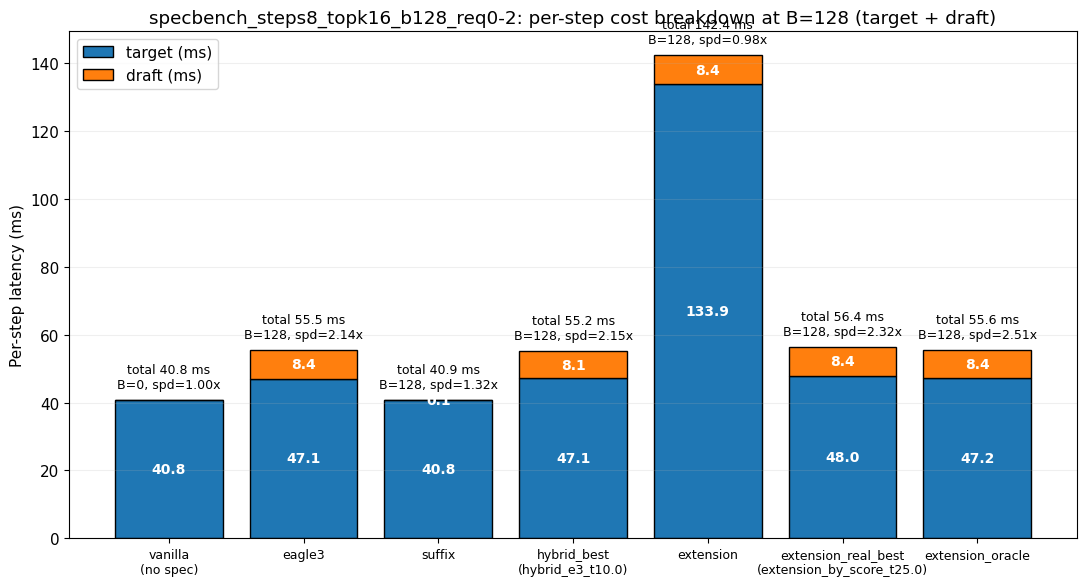

In [26]:
# Stacked bars: per-step cost breakdown (target + draft, in ms) for
# 5 key methods. Each bar uses that method's best-speedup budget.
# 'extension_real_best' = whichever realistic extension_* variant has
# the highest speedup (oracles excluded).

# Unified budget: the B at which eagle3 achieves its best speedup.
# All methods are evaluated at that same B so the bars are directly
# comparable (same verify budget, different draft/verify trees).
_eagle3_col = 'eagle3_speedup_real'
if _eagle3_col in df.columns:
    _UNIFIED_B = int(df.loc[df[_eagle3_col].idxmax(), 'budget'])
else:
    _UNIFIED_B = int(df['budget'].median())
print(f'Unified budget = {_UNIFIED_B} (eagle3\'s best)')

def _method_row_at_B(name, B):
    col = f'{name}_speedup_real'
    if col not in df.columns:
        return None
    sub = df[df['budget'] == B]
    if sub.empty:
        return None
    return sub.iloc[0]

def _pick_ext_real_best():
    best, best_spd = None, -1
    for c in df.columns:
        if not c.endswith('_speedup_real'):
            continue
        nm = c[:-len('_speedup_real')]
        if not nm.startswith('extension'):
            continue
        if nm.endswith('_oracle') or nm in ('extension', 'extension_dmsfx'):
            continue
        if '_dmsfx' in nm:  # skip DM base variants, focus on E3+Sfx
            continue
        v = df[c].max()
        if v is not None and v > best_spd:
            best_spd, best = v, nm
    return best

ext_real_best_name = _pick_ext_real_best()
# Also pick best hybrid (Sfx→E3 or Sfx→DM) by speedup for reference.
def _pick_hybrid_best():
    best, best_spd = None, -1
    for c in df.columns:
        if not c.endswith('_speedup_real') or c.endswith('_always_speedup_real'):
            continue
        nm = c[:-len('_speedup_real')]
        if not (nm.startswith('hybrid_e3_t') or nm.startswith('hybrid_dm_t')):
            continue
        v = df[c].max()
        if v is not None and v > best_spd:
            best_spd, best = v, nm
    return best

hybrid_best_name = _pick_hybrid_best()
METHOD_ENTRIES = [
    ('vanilla', 'vanilla'),
    ('eagle3', 'eagle3'),
    ('suffix', 'suffix'),
    ('hybrid_best', hybrid_best_name or 'eagle3'),
    ('extension', 'extension'),
    ('extension_real_best', ext_real_best_name or 'extension'),
    ('extension_oracle', 'extension_oracle'),
]

labels, target_ms, draft_ms, budgets, speedups = [], [], [], [], []
for label, real_name in METHOD_ENTRIES:
    if real_name == 'vanilla':
        labels.append('vanilla\n(no spec)')
        target_ms.append(vanilla_ms)
        draft_ms.append(0.0)
        budgets.append(0)
        speedups.append(1.0)
        continue
    row = _method_row_at_B(real_name, _UNIFIED_B)
    if row is None:
        labels.append(label + '\n(missing)')
        target_ms.append(0); draft_ms.append(0)
        budgets.append(0); speedups.append(0)
        continue
    B = int(row['budget'])
    steps = int(row.get(f'{real_name}_steps', 0)) or 1
    t = float(row.get(f'{real_name}_total_target_ms', 0)) / steps
    d = float(row.get(f'{real_name}_total_draft_ms', 0)) / steps
    spd = float(row.get(f'{real_name}_speedup_real', 0))
    disp_name = real_name if label in ('extension_real_best', 'hybrid_best') else ''
    labels.append(f'{label}' + (f'\n({disp_name})' if disp_name else ''))
    target_ms.append(t); draft_ms.append(d)
    budgets.append(B); speedups.append(spd)

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x, target_ms, color='#1f77b4', edgecolor='black',
            label='target (ms)')
b2 = ax.bar(x, draft_ms, bottom=target_ms, color='#ff7f0e',
            edgecolor='black', label='draft (ms)')

for i, (t, d, B, spd) in enumerate(zip(target_ms, draft_ms, budgets, speedups)):
    total = t + d
    if total <= 0:
        continue
    if t > 0:
        ax.text(i, t / 2, f'{t:.1f}', ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')
    if d > 0:
        ax.text(i, t + d / 2, f'{d:.1f}', ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')
    ax.text(i, total + max(target_ms + draft_ms) * 0.02,
            f'total {total:.1f} ms\nB={B}, spd={spd:.2f}x',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Per-step latency (ms)')
ax.set_title(f'{SELECTED}: per-step cost breakdown at B={_UNIFIED_B} (target + draft)')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


## 12. Draft vs Accept Tokens per Step

Target forward 에 들어간 draft token 수 vs 실제로 accept 된 token 수 (step 평균).
Accept / draft 비율은 spec decoding 의 효율성 지표.


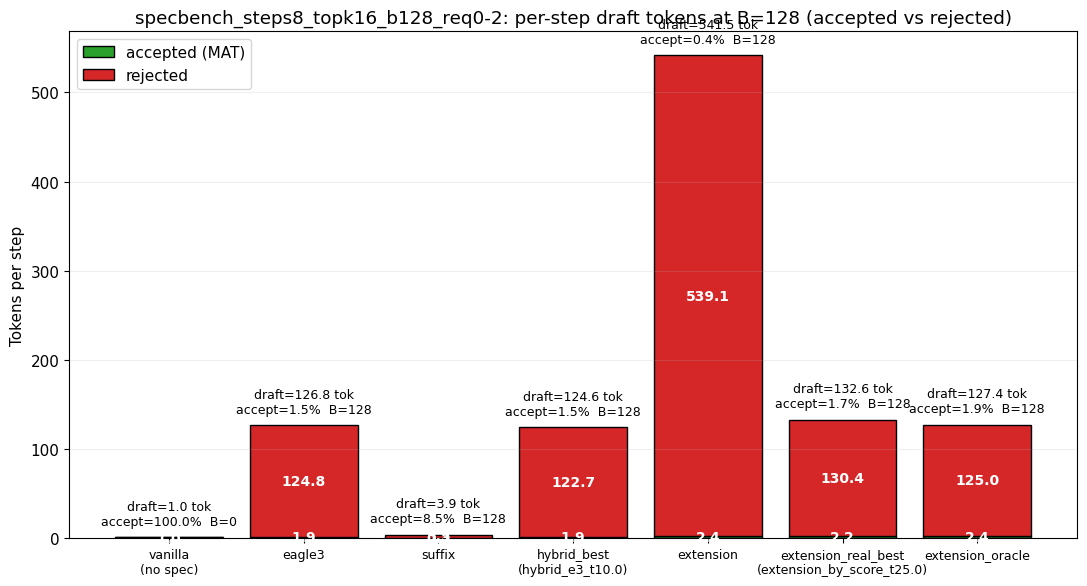

In [27]:
# Stacked bars: per-step draft token split (accepted vs rejected) for
# the same 5 methods. Draft tokens = tree size fed into target forward.
# Accepted = MAT. Rejected = draft_tokens − MAT.

def _token_row(name):
    # Use unified budget (from §11) so bars line up.
    col = f'{name}_speedup_real'
    if col not in df.columns:
        return None, None, None
    sub = df[df['budget'] == _UNIFIED_B]
    if sub.empty:
        return None, None, None
    r = sub.iloc[0]
    steps = int(r.get(f'{name}_steps', 0)) or 1
    dt_col = f'{name}_total_target_tokens'
    mat = float(r.get(f'{name}_mat', 0))
    if dt_col in df.columns:
        draft_tokens = float(r[dt_col]) / steps
    else:
        draft_tokens = float(r['budget'])
    return draft_tokens, mat, int(r['budget'])

labels, accepted, rejected, budgets = [], [], [], []
for label, real_name in METHOD_ENTRIES:
    if real_name == 'vanilla':
        # vanilla has no draft tokens (single-token decode). Show bar=0.
        labels.append('vanilla\n(no spec)')
        accepted.append(1.0); rejected.append(0.0); budgets.append(0)
        continue
    dt, mat, B = _token_row(real_name)
    if dt is None:
        labels.append(label + '\n(missing)')
        accepted.append(0); rejected.append(0); budgets.append(0)
        continue
    rej = max(0.0, dt - mat)
    disp_name = real_name if label in ('extension_real_best', 'hybrid_best') else ''
    labels.append(f'{label}' + (f'\n({disp_name})' if disp_name else ''))
    accepted.append(mat); rejected.append(rej); budgets.append(B)

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x, accepted, color='#2ca02c', edgecolor='black', label='accepted (MAT)')
ax.bar(x, rejected, bottom=accepted, color='#d62728', edgecolor='black',
       label='rejected')

for i, (a, r, B) in enumerate(zip(accepted, rejected, budgets)):
    total = a + r
    if total <= 0:
        continue
    if a > 0:
        ax.text(i, a / 2, f'{a:.1f}', ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')
    if r > 0:
        ax.text(i, a + r / 2, f'{r:.1f}', ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')
    pct = 100 * a / total if total > 0 else 0
    ax.text(i, total + max(accepted + rejected) * 0.02,
            f'draft={total:.1f} tok\naccept={pct:.1f}%  B={B}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Tokens per step')
ax.set_title(f'{SELECTED}: per-step draft tokens at B={_UNIFIED_B} (accepted vs rejected)')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


## 12b. Draft Tokens per Step — Distribution

Method별로 per-step draft tokens(= target forward에 들어간 tree size) 분포를 boxplot 스타일로 표시.
whisker = min/max across steps, box = mean ± std, line = mean.
simulator 에 `total_target_tokens_sq/min/max` 필드가 있어야 그려짐 (없으면 재시뮬 필요).


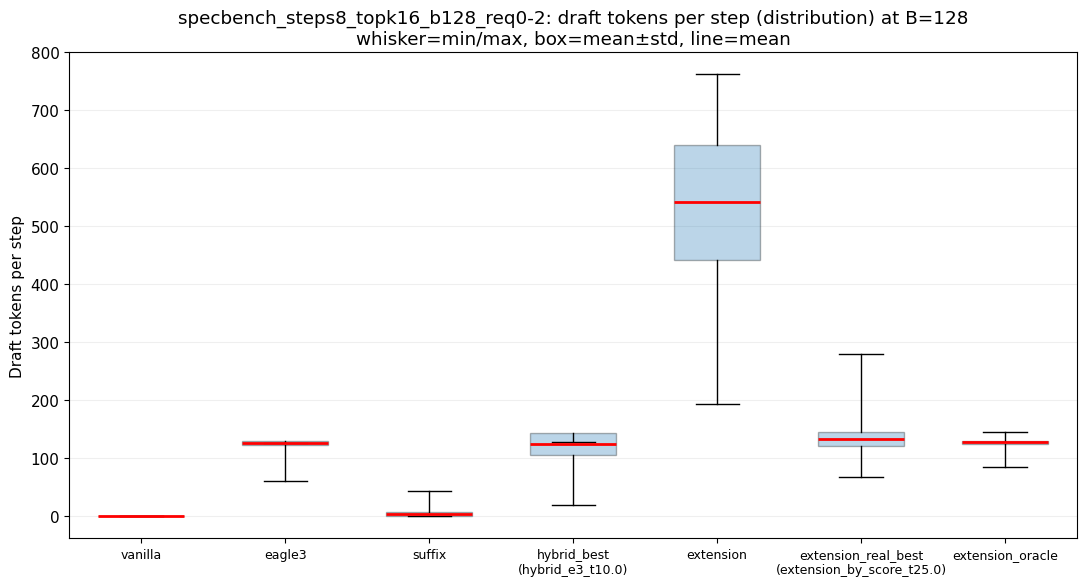


method                              mean     std   min   max
vanilla                             1.00    0.00     1     1
eagle3                            126.75    3.18    61   127
suffix                              3.87    3.91     1    44
hybrid_best
(hybrid_e3_t10.0)     124.57   18.35    20   128
extension                         541.51   99.63   193   762
extension_real_best
(extension_b  132.58   11.98    68   279
extension_oracle                  127.44    2.69    85   145


In [28]:
# Draft-tokens-per-step distribution using per-step stats
# (total_target_tokens, _sq, _min, _max). All evaluated at the
# unified eagle3-best budget used by §11 and §12.
import math as _math

def _dist_at_B(name, B):
    sub = df[df['budget'] == B]
    if sub.empty:
        return None
    r = sub.iloc[0]
    steps = int(r.get(f'{name}_steps', 0)) or 1
    total = r.get(f'{name}_total_target_tokens')
    sq = r.get(f'{name}_total_target_tokens_sq')
    mn = r.get(f'{name}_total_target_tokens_min')
    mx = r.get(f'{name}_total_target_tokens_max')
    if total is None:
        return None
    mean = float(total) / steps
    if sq is None or (isinstance(sq, float) and _math.isnan(sq)):
        std = 0.0
    else:
        var = float(sq) / steps - mean * mean
        std = _math.sqrt(max(0.0, var))
    return {
        'mean': mean, 'std': std,
        'min': float(mn) if mn is not None else mean,
        'max': float(mx) if mx is not None else mean,
    }

labels = []
boxes = []
for label, real_name in METHOD_ENTRIES:
    if real_name == 'vanilla':
        labels.append('vanilla')
        boxes.append({'med': 1, 'q1': 1, 'q3': 1, 'whislo': 1, 'whishi': 1})
        continue
    dist = _dist_at_B(real_name, _UNIFIED_B)
    if dist is None:
        labels.append(label + '\n(missing)')
        boxes.append({'med': 0, 'q1': 0, 'q3': 0, 'whislo': 0, 'whishi': 0})
        continue
    # Box = mean ± std, whiskers = min/max observed per step
    lo = max(0, dist['mean'] - dist['std'])
    hi = dist['mean'] + dist['std']
    boxes.append({
        'med': dist['mean'],
        'q1': lo, 'q3': hi,
        'whislo': dist['min'], 'whishi': dist['max'],
    })
    disp = real_name if label in ('extension_real_best', 'hybrid_best') else ''
    labels.append(f'{label}' + (f'\n({disp})' if disp else ''))

fig, ax = plt.subplots(figsize=(11, 6))
ax.bxp(boxes, positions=range(len(boxes)), widths=0.6, showfliers=False,
       boxprops=dict(facecolor='#1f77b4', alpha=0.3, edgecolor='black'),
       medianprops=dict(color='red', linewidth=2),
       whiskerprops=dict(color='black'),
       capprops=dict(color='black'),
       patch_artist=True)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Draft tokens per step')
ax.set_title(
    f'{SELECTED}: draft tokens per step (distribution) at B={_UNIFIED_B}\n'
    f'whisker=min/max, box=mean±std, line=mean')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# Summary table
print()
print(f"{'method':<32} {'mean':>7} {'std':>7} {'min':>5} {'max':>5}")
for label, b in zip(labels, boxes):
    print(f"{label[:32]:<32} {b['med']:>7.2f} {(b['q3']-b['med']):>7.2f} {b['whislo']:>5.0f} {b['whishi']:>5.0f}")


## 13. 기법 구현 상세

각 기법이 **Stage 6 Oracle Simulator** (`simulation/evaluation/run_tree_oracle_sim.py`)
에서 어떻게 구현되었는지 간단히 정리. 모든 기법은 동일한 trajectory
(EAGLE3 trace + Suffix cache + draft-model drafts) 위에서 budget B
(verifier slot 수) 를 놓고 speedup 을 계산한다.

### 0) 베이스라인 (single proposer)

| 기법 | 제안 트리 | 검증 로직 |
|---|---|---|
| `EAGLE3` (single:eagle3) | 최대 B 개의 노드 (step × topk) | Verify 1 회; accept 만큼 커밋 |
| `Suffix` (single:suffix) | SuffixDecodingCache.speculate() 의 tree 그대로 | 동일 |
| `Draft Model` (single:draft_model) | 길이 min(B, 16) 의 chain | 동일 |

### 1) Hybrid (Sfx → E3 / Sfx → DM)

**아이디어**: suffix 가 현재 step 에서 긴 체인을 만들어낼 수 있으면 (score ≥ threshold t) **suffix 트리**를 verify, 아니면 base proposer 트리를 verify.

- 한 step 당 Verify 는 1 회 뿐이므로 이전 검증 비용을 두 배로 쓰지 않음.
- `hybrid_*_always` variant 는 score 와 무관하게 항상 suffix 쓰는 것 — 비교용.
- threshold t ∈ {1, 2, 3, 5, 10, 20} 스위프, main chart 에는 각 base 별 최고 threshold 만 남김.

### 2) Extension (base tree + suffix 를 모든 노드에 확장)

**아이디어**: E3 트리(또는 DM chain)의 **각 노드 끝에 suffix draft 를 붙여** 한 번의 target verify 로 검증. Base 트리의 어떤 노드가 accept 되든, 그 뒤의 suffix 체인까지 한 스텝에 같이 accept 가능.

- **no constraint** (`extension`, `extension_dmsfx`): base tree 의 **모든** 노드에 suffix 확장.
- **oracle** (`extension_oracle`, `extension_dmsfx_oracle`): 실제로 accept 된 경로에만 suffix 붙였다고 가정한 **upper bound** — 배포 불가능, 성능 천장 측정용.

### 3) Extension — filter variants (어느 노드에 suffix 붙일까)

E3 트리 위에서 **어떤 노드에 한해서만** suffix 확장을 하느냐로 여러 파생.

**공통 재료**:
- `suffix_draft.score`: SuffixDecodingCache 가 반환하는 draft chain 의
  빈도/점수 (pre-verify 에 이미 알려진 값, realistic).

| family | 필터 조건 | 의도 |
|---|---|---|
| `count` | 총 tree size ≤ **C = budget** — base tree 에서 시작해 suffix extension 을 순차 attach 하다 cap 에 도달하면 stop | 전체 tree 크기를 budget 으로 직접 제한 |
| `score` (t ∈ {1,2,3,5,10,20}) | `suffix_draft.score ≥ t` 인 노드만 | suffix 체인이 충분히 길 때만 붙임 |

> model 의 verify softmax (Stage 1 에서 capture 한 `target_p_t`) 를
> 필터 입력으로 사용. 실제 배포에서는 tree 를 **고르기 전** 에 이 값을
> 알 수 없으므로 unrealistic. 현재 차트에서 제외, artifact 에는 그대로
> 남아 있음.

### 4) 검증 비용 모델 (real cost)

- Target forward: `target_forward_ms[min(B, actual_tree_size)]` — 실제 verify 한 tree size 만큼만 과금. Budget 을 초과한 경우 interp/extrap.
- Draft only:
  - EAGLE3: `eagle3_draft_ms[B]`
  - Suffix: 0ms (CPU speculate, negligible vs GPU step)
  - Draft Model: `min(B, 16) × draft_lm_tpot_ms`
- Step = target + draft. Speedup = `N_steps(vanilla) × vanilla_step_ms / Σ step_i`.

### 5) MAT (Mean Accepted Tokens)

한 step 당 `accept_length + 1` 토큰이 커밋. MAT = 총 커밋 토큰 / step 수. Speedup 의 상한선 (if draft 가 무료라면 speedup ≈ MAT).
